In [3]:
from faker import Faker

In [4]:
import pandas as pd 

In [2]:
pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 524.3 kB/s eta 0:00:03
   ---------- ----------------------------- 0.5/2.0 MB 524.3 kB/s eta 0:00:03
   ---------- ----------------------------- 0.5/2.0 MB 524.3 kB/s eta 0:00:03
   --------------- ------------------------ 0.8/2.0 MB 441.3 kB/s eta 0:00:03
   --------------- ------------------------ 0.8/2.0 MB 441.3 kB/s eta 0:00:03
   --------------- ------------------------ 0.8/2.0 MB 441

In [5]:
import random

In [6]:
fake = Faker("es_MX")

In [29]:
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18, 65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(["Tiktok", "Instagram", "Youtube"])
    })

In [30]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Reynaldo Antonio Cavazos,wnieves@example.net,48,15533,Instagram
1,2,Antonio Acuña Vergara,ramosmaximiliano@example.net,42,42150,Tiktok
2,3,María Cristina Espino Henríquez,jaimevictor@example.org,24,37077,Youtube
3,4,Juan Cristobal Castañeda,gchacon@example.com,57,26731,Instagram
4,5,Olivia Luisa Ávila,olivaresalejandra@example.net,42,41846,Instagram


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      1000 non-null   str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [32]:
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,999,999,NaN,NaN,3
top,NaN,Roberto Romo,sarredondo@example.com,NaN,NaN,Instagram
freq,NaN,2,2,NaN,NaN,340
mean,500.500000,NaN,NaN,41.718000,25614.886000,NaN
std,288.819436,NaN,NaN,13.854762,14611.162105,NaN
min,1.000000,NaN,NaN,18.000000,210.000000,NaN
25%,250.750000,NaN,NaN,29.000000,12951.500000,NaN
50%,500.500000,NaN,NaN,42.000000,26006.000000,NaN
75%,750.250000,NaN,NaN,54.000000,38552.750000,NaN


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

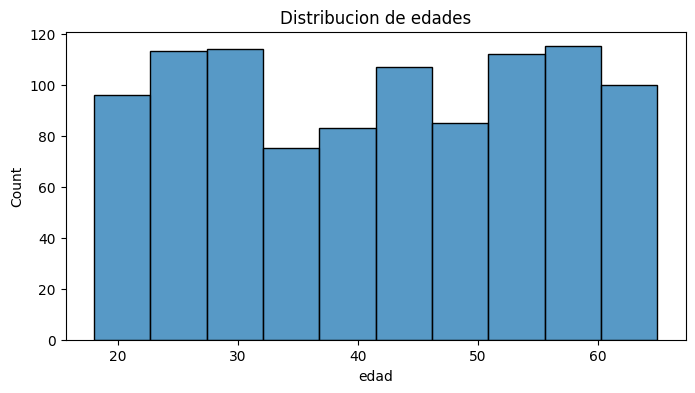

In [34]:
#Distribucion de edades}
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

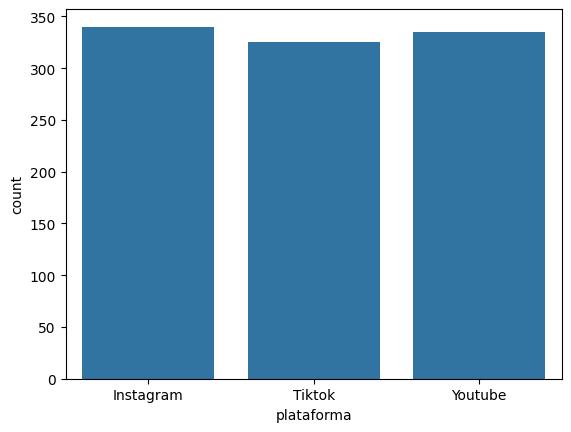

In [35]:
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [36]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [37]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"]= None

In [38]:
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      995 non-null    str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [39]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [40]:
df_sucio.describe()["edad"]

count    1000.000000
mean       41.481000
std        14.276886
min       -10.000000
25%        29.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: edad, dtype: float64

In [41]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 5000000

In [42]:
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     5.048111e+04
std      3.513415e+05
min      2.100000e+02
25%      1.295150e+04
50%      2.609000e+04
75%      3.892425e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [43]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"]="correo_invalido"

In [44]:
df_sucio.describe(include=["str","object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,994,995,3
top,Roberto Romo,correo_invalido,Instagram
freq,2,5,340


In [45]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [48]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,994,995,NaN,NaN,3
top,NaN,Roberto Romo,correo_invalido,NaN,NaN,Instagram
freq,NaN,2,5,NaN,NaN,340
mean,500.50,NaN,NaN,41.48,50481.11,NaN
std,288.82,NaN,NaN,14.28,351341.46,NaN
min,1.00,NaN,NaN,-10.00,210.00,NaN
25%,250.75,NaN,NaN,29.00,12951.50,NaN
50%,500.50,NaN,NaN,42.00,26090.00,NaN
75%,750.25,NaN,NaN,54.00,38924.25,NaN


In [47]:
pd.set_option('display.float_format',lambda x:'%.2f' % x)